### Mount Google Drive

First, we need to mount your Google Drive to access the file. When you run the following cell, you will be prompted to authorize Colab to access your Google Drive files. Follow the instructions to complete the mounting process.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load the Excel file

Now that your Drive is mounted, we can specify the path to your Excel file and load it into a pandas DataFrame. Make sure to replace `'Your_path_to_Online_retail_II.xlsx'` with the actual path to your file in Google Drive. For example, if it's in the root of your drive, the path would be `/content/drive/MyDrive/Online_retail_II.xlsx`.

In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/online+retail+ii (1).zip'
extract_to_path = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

print(f"File extracted to: {extract_to_path}")
print(f"Contents of {extract_to_path}: {os.listdir(extract_to_path)}")

File extracted to: /content/
Contents of /content/: ['.config', 'drive', 'online_retail_II.xlsx', 'sample_data']


In [ ]:
import pandas as pd

# Using the path for the unzipped file
file_path = '/content/online_retail_II.xlsx'

# Load the two sheets from the Excel file
raw_2009_2010 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
raw_2010_2011 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

print(f"2009-2010 Shape: {raw_2009_2010.shape}")
print(f"2010-2011 Shape: {raw_2010_2011.shape}")

display(raw_2009_2010.head())
display(raw_2010_2011.head())

2009-2010 Shape: (525461, 8)
2010-2011 Shape: (541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


CLEANING FUNCTION



In [ ]:
def clean_online_retail(df_raw, year_label):
    dfc = df_raw.copy()

    # 1) Standardize column names
    dfc.columns = [c.strip().lower().replace(' ', '_') for c in dfc.columns]
    dfc = dfc.rename(columns={
        'invoice': 'invoice_no',
        'stockcode': 'stock_code',
        'invoicedate': 'invoice_date',
        'price': 'unit_price',
        'customer_id': 'customer_id'
    })

    # 2) Coerce types
    dfc['invoice_no'] = dfc['invoice_no'].astype(str).str.strip()
    dfc['stock_code'] = dfc['stock_code'].astype(str).str.strip()

    dfc['description'] = dfc['description'].astype('string').str.strip()
    dfc.loc[dfc['description'].isna() | (dfc['description'].str.len() == 0), 'description'] = pd.NA

    dfc['country'] = dfc['country'].astype('string').str.strip()

    dfc['invoice_date'] = pd.to_datetime(dfc['invoice_date'], errors='coerce')
    dfc['quantity'] = pd.to_numeric(dfc['quantity'], errors='coerce')
    dfc['unit_price'] = pd.to_numeric(dfc['unit_price'], errors='coerce')
    dfc['customer_id'] = pd.to_numeric(dfc['customer_id'], errors='coerce')

    # 3) Flags
    dfc['is_cancelled'] = dfc['invoice_no'].str.upper().str.startswith('C')
    dfc['has_customer_id'] = dfc['customer_id'].notna()

    # 4) Drop rows missing essentials
    dfc = dfc[dfc['invoice_date'].notna()].copy()
    dfc = dfc[dfc['stock_code'].notna()].copy()
    dfc = dfc[dfc['quantity'].notna()].copy()
    dfc = dfc[dfc['unit_price'].notna()].copy()

    # 5) Remove distortion-heavy values for standard EDA
    # Keep cancellations in the dataset (they're meaningful), but remove zero qty and non-positive price
    dfc = dfc[(dfc['unit_price'] > 0) & (dfc['quantity'] != 0)].copy()

    # 6) Derived fields for EDA
    dfc['line_revenue'] = dfc['quantity'] * dfc['unit_price']
    dfc['year_sheet'] = year_label
    dfc['invoice_day'] = dfc['invoice_date'].dt.date
    dfc['invoice_month'] = dfc['invoice_date'].dt.to_period('M').astype(str)

    # 7) Remove exact duplicate rows
    dfc = dfc.drop_duplicates()

    return dfc

CLEAN EACH SHEET + COMBINE

In [ ]:
clean_0910 = clean_online_retail(raw_2009_2010, '2009-2010')
clean_1011 = clean_online_retail(raw_2010_2011, '2010-2011')

online_retail_clean = pd.concat([clean_0910, clean_1011], ignore_index=True)

print(clean_0910.shape)
print(clean_1011.shape)
print(online_retail_clean.shape)

print(online_retail_clean.head())

(514912, 14)
(534130, 14)
(1049042, 14)
  invoice_no stock_code                          description  quantity  \
0     489434      85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1     489434     79323P                   PINK CHERRY LIGHTS        12   
2     489434     79323W                  WHITE CHERRY LIGHTS        12   
3     489434      22041          RECORD FRAME 7" SINGLE SIZE        48   
4     489434      21232       STRAWBERRY CERAMIC TRINKET BOX        24   

         invoice_date  unit_price  customer_id         country  is_cancelled  \
0 2009-12-01 07:45:00        6.95      13085.0  United Kingdom         False   
1 2009-12-01 07:45:00        6.75      13085.0  United Kingdom         False   
2 2009-12-01 07:45:00        6.75      13085.0  United Kingdom         False   
3 2009-12-01 07:45:00        2.10      13085.0  United Kingdom         False   
4 2009-12-01 07:45:00        1.25      13085.0  United Kingdom         False   

   has_customer_id  line_revenue y

 Create EDA-ready “default” view (remove cancellations)

 For most sales EDA you’ll want purchases only (no returns/cancellations). We keep cancellations separately for later analysis.



In [ ]:
online_retail_eda = online_retail_clean.loc[~online_retail_clean['is_cancelled']].copy()
online_retail_returns = online_retail_clean.loc[online_retail_clean['is_cancelled']].copy()

print(online_retail_eda.shape)
print(online_retail_returns.shape)

print(online_retail_eda.head())
print(online_retail_returns.head())

(1029609, 14)
(19433, 14)
  invoice_no stock_code                          description  quantity  \
0     489434      85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1     489434     79323P                   PINK CHERRY LIGHTS        12   
2     489434     79323W                  WHITE CHERRY LIGHTS        12   
3     489434      22041          RECORD FRAME 7" SINGLE SIZE        48   
4     489434      21232       STRAWBERRY CERAMIC TRINKET BOX        24   

         invoice_date  unit_price  customer_id         country  is_cancelled  \
0 2009-12-01 07:45:00        6.95      13085.0  United Kingdom         False   
1 2009-12-01 07:45:00        6.75      13085.0  United Kingdom         False   
2 2009-12-01 07:45:00        6.75      13085.0  United Kingdom         False   
3 2009-12-01 07:45:00        2.10      13085.0  United Kingdom         False   
4 2009-12-01 07:45:00        1.25      13085.0  United Kingdom         False   

   has_customer_id  line_revenue year_sheet invo

 Quick sanity checks (optional but recommended before EDA)
This step checks missingness and a few “does this look reasonable?” counts.


In [ ]:
print(online_retail_clean.isna().mean().sort_values(ascending=False) * 100)

print((online_retail_clean['unit_price'] <= 0).sum())
print((online_retail_clean['quantity'] == 0).sum())

print(online_retail_clean['invoice_no'].nunique())
print(online_retail_eda['invoice_no'].nunique())

customer_id        22.567733
invoice_no          0.000000
description         0.000000
quantity            0.000000
invoice_date        0.000000
stock_code          0.000000
unit_price          0.000000
country             0.000000
is_cancelled        0.000000
has_customer_id     0.000000
line_revenue        0.000000
year_sheet          0.000000
invoice_day         0.000000
invoice_month       0.000000
dtype: float64
0
0
48369
40077


In [ ]:
print("\nDescriptive statistics for numerical columns in online_retail_eda:")
display(online_retail_eda.describe())

print("\nDataFrame Info (data types, non-null counts, memory usage):")
online_retail_eda.info()


Descriptive statistics for numerical columns in online_retail_eda:


,quantity,invoice_date,unit_price,customer_id,line_revenue
count,1.029609e+06,1029609,1.029609e+06,793609.000000,1.029609e+06
mean,1.105795e+01,2011-01-03 19:35:55.374282752,4.094842e+00,15325.072507,2.031246e+01
min,1.000000e+00,2009-12-01 07:45:00,1.000000e-03,12346.000000,1.000000e-03
25%,1.000000e+00,2010-07-12 10:54:00,1.250000e+00,13975.000000,4.130000e+00
50%,3.000000e+00,2010-12-07 18:36:00,2.100000e+00,15255.000000,1.008000e+01
75%,1.200000e+01,2011-07-24 12:05:00,4.150000e+00,16797.000000,1.770000e+01
max,8.099500e+04,2011-12-09 12:50:00,2.511109e+04,18287.000000,1.684696e+05
std,1.272405e+02,NaN,5.174728e+01,1697.397406,2.042938e+02



DataFrame Info (data types, non-null counts, memory usage):
<class 'pandas.core.frame.DataFrame'>
Index: 1029609 entries, 0 to 1049041
Data columns (total 14 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   invoice_no       1029609 non-null  object        
 1   stock_code       1029609 non-null  object        
 2   description      1029609 non-null  string        
 3   quantity         1029609 non-null  int64         
 4   invoice_date     1029609 non-null  datetime64[ns]
 5   unit_price       1029609 non-null  float64       
 6   customer_id      793609 non-null   float64       
 7   country          1029609 non-null  string        
 8   is_cancelled     1029609 non-null  bool          
 9   has_customer_id  1029609 non-null  bool          
 10  line_revenue     1029609 non-null  float64       
 11  year_sheet       1029609 non-null  object        
 12  invoice_day      1029609 non-null  object        
 13  i

### Distribution of Quantity

Let's visualize the distribution of the `quantity` column using a histogram to identify potential outliers.

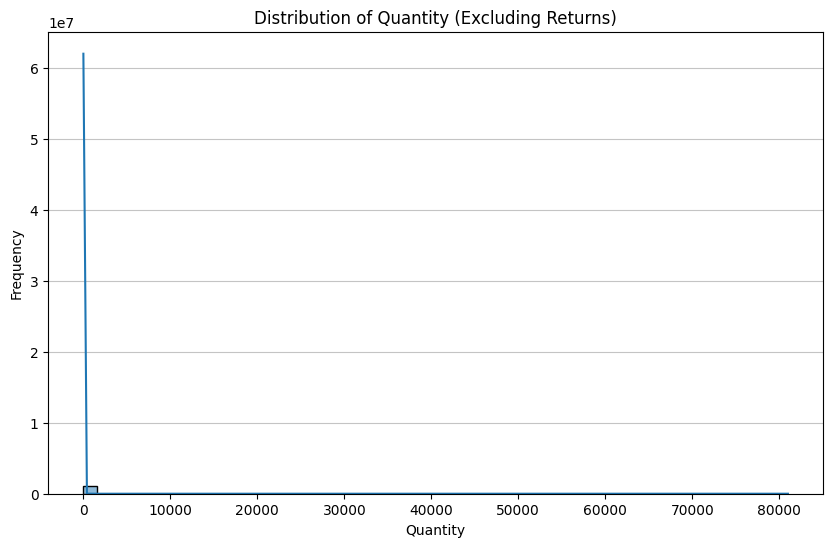

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(online_retail_eda['quantity'], bins=50, kde=True)
plt.title('Distribution of Quantity (Excluding Returns)')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Outlier Analysis: Quantity

From the histogram, we saw a long tail indicating large quantities. Let's use a box plot to get a clearer view of outliers in the `quantity` column. We will also set a reasonable upper bound for visualization, as extreme outliers can make the plot unreadable.

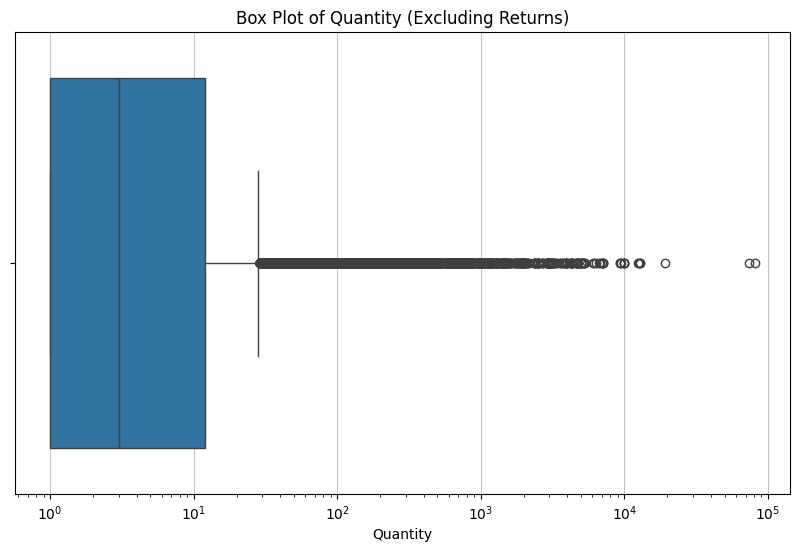

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=online_retail_eda['quantity'])
plt.title('Box Plot of Quantity (Excluding Returns)')
plt.xlabel('Quantity')
plt.xscale('log') # Use a log scale to better visualize the wide range of values
plt.grid(axis='x', alpha=0.75)
plt.show()

### Outlier Analysis: Unit Price

Similarly, let's examine the `unit_price` column for outliers. This is crucial as extreme prices can heavily skew revenue calculations and other analyses.

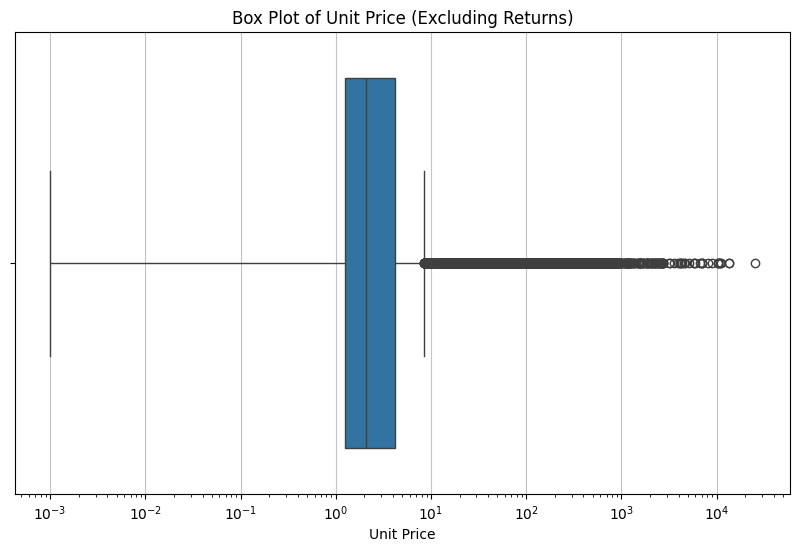

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=online_retail_eda['unit_price'])
plt.title('Box Plot of Unit Price (Excluding Returns)')
plt.xlabel('Unit Price')
plt.xscale('log') # Use a log scale for better visualization if values span several orders of magnitude
plt.grid(axis='x', alpha=0.75)
plt.show()

### Addressing Missing Customer IDs

We previously noted that approximately 22.57% of `customer_id` values are missing. Depending on the analysis, these rows might need to be handled. Here are a few common strategies:

1.  **Drop rows with missing `customer_id`**: If the analysis strictly requires customer identification (e.g., for RFM analysis, customer segmentation), these rows can be dropped.
2.  **Impute missing values**: If possible, missing IDs could be imputed (though this is often difficult and risky for unique identifiers).
3.  **Treat as 'guest' purchases**: Assign a new, unique identifier (e.g., 'Guest') to all transactions without a `customer_id` if the goal is to analyze overall sales without individual customer tracking.

For most customer-centric analyses, dropping them is often the safest bet. However, for overall sales trend analysis, they can still contribute to `line_revenue` if other data is complete.

### Sales Distribution by Country

To understand where the sales are coming from, let's analyze the `line_revenue` by `country`. We'll calculate the total revenue for each country and visualize the top countries.

Top 10 Countries by Sales Revenue:


,country,line_revenue
0,United Kingdom,1.781406e+07
1,EIRE,6.640501e+05
2,Netherlands,5.542307e+05
3,Germany,4.307038e+05
4,France,3.567465e+05
5,Australia,1.699006e+05
6,Spain,1.091272e+05
7,Switzerland,1.009890e+05
8,Sweden,9.186982e+04
9,Denmark,6.986219e+04


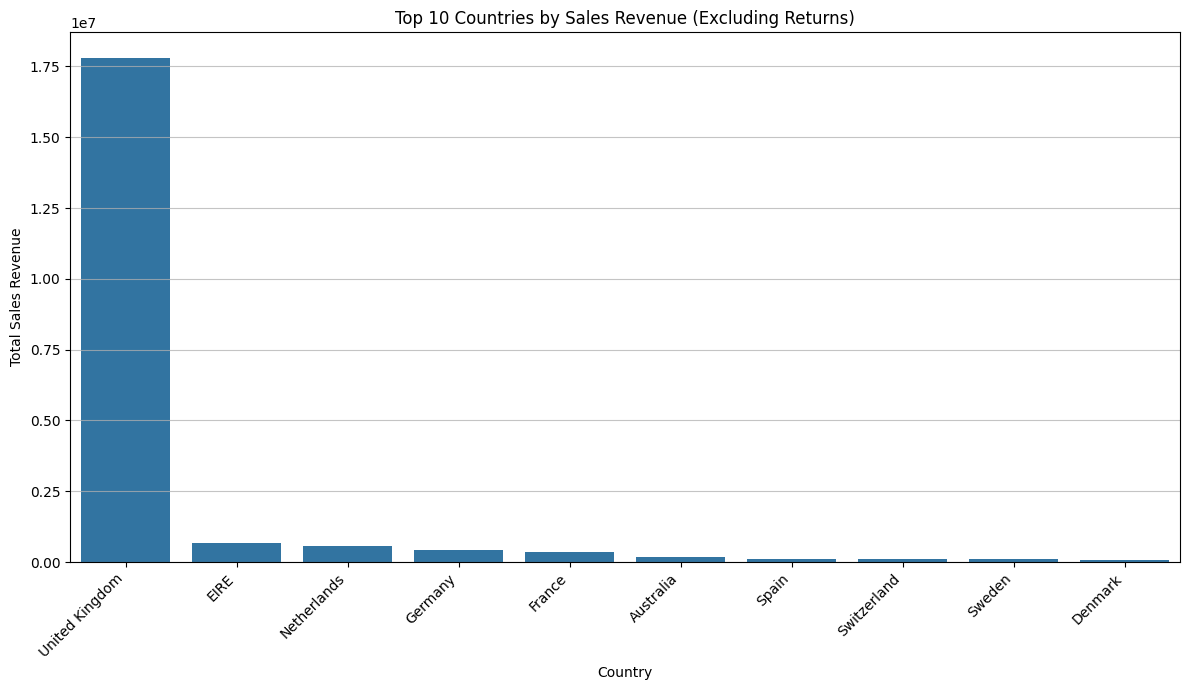

In [ ]:
country_sales = online_retail_eda.groupby('country')['line_revenue'].sum().sort_values(ascending=False).reset_index()

print('Top 10 Countries by Sales Revenue:')
display(country_sales.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='country', y='line_revenue', data=country_sales.head(10))
plt.title('Top 10 Countries by Sales Revenue (Excluding Returns)')
plt.xlabel('Country')
plt.ylabel('Total Sales Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Detailed Null Analysis for `online_retail_eda`

Although we performed a general null check earlier, let's look specifically at the `online_retail_eda` DataFrame, which excludes cancelled transactions, to confirm its completeness. Understanding the extent of missing values is vital for subsequent analysis.

In [ ]:
print('Percentage of missing values in each column of online_retail_eda:')
print(online_retail_eda.isna().mean().sort_values(ascending=False) * 100)

Percentage of missing values in each column of online_retail_eda:
customer_id        22.921323
invoice_no          0.000000
description         0.000000
quantity            0.000000
invoice_date        0.000000
stock_code          0.000000
unit_price          0.000000
country             0.000000
is_cancelled        0.000000
has_customer_id     0.000000
line_revenue        0.000000
year_sheet          0.000000
invoice_day         0.000000
invoice_month       0.000000
dtype: float64


### Summary Statistics for `online_retail_eda`

We briefly looked at `describe()` earlier, but let's re-examine the descriptive statistics for our main EDA DataFrame (`online_retail_eda`) to get a quick overview of the central tendency, dispersion, and shape of its distribution for numerical data.

In [ ]:
display(online_retail_eda.describe())

,quantity,invoice_date,unit_price,customer_id,line_revenue
count,1.029609e+06,1029609,1.029609e+06,793609.000000,1.029609e+06
mean,1.105795e+01,2011-01-03 19:35:55.374282752,4.094842e+00,15325.072507,2.031246e+01
min,1.000000e+00,2009-12-01 07:45:00,1.000000e-03,12346.000000,1.000000e-03
25%,1.000000e+00,2010-07-12 10:54:00,1.250000e+00,13975.000000,4.130000e+00
50%,3.000000e+00,2010-12-07 18:36:00,2.100000e+00,15255.000000,1.008000e+01
75%,1.200000e+01,2011-07-24 12:05:00,4.150000e+00,16797.000000,1.770000e+01
max,8.099500e+04,2011-12-09 12:50:00,2.511109e+04,18287.000000,1.684696e+05
std,1.272405e+02,NaN,5.174728e+01,1697.397406,2.042938e+02


### Distribution Plots for Key Numerical Variables

We have already visualized the distributions for `quantity` and `unit_price`. Let's also look at the distribution of `line_revenue` to understand the revenue generated per transaction line.

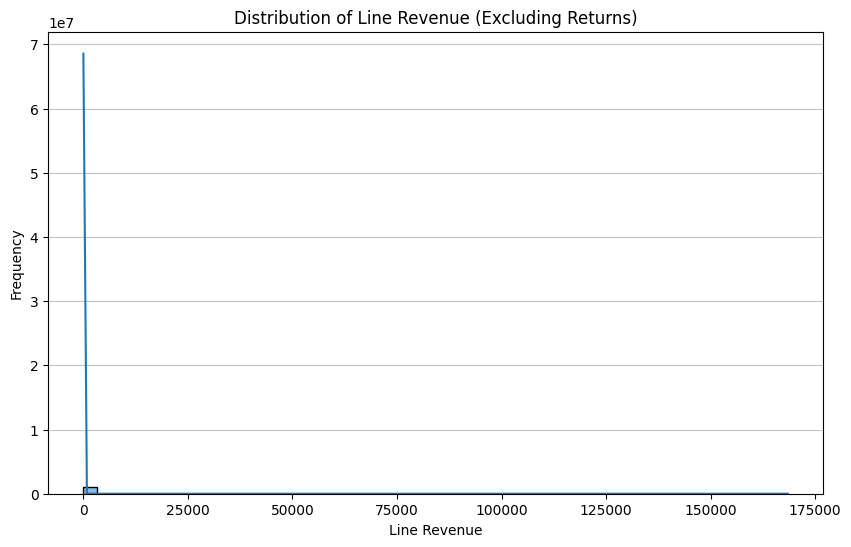

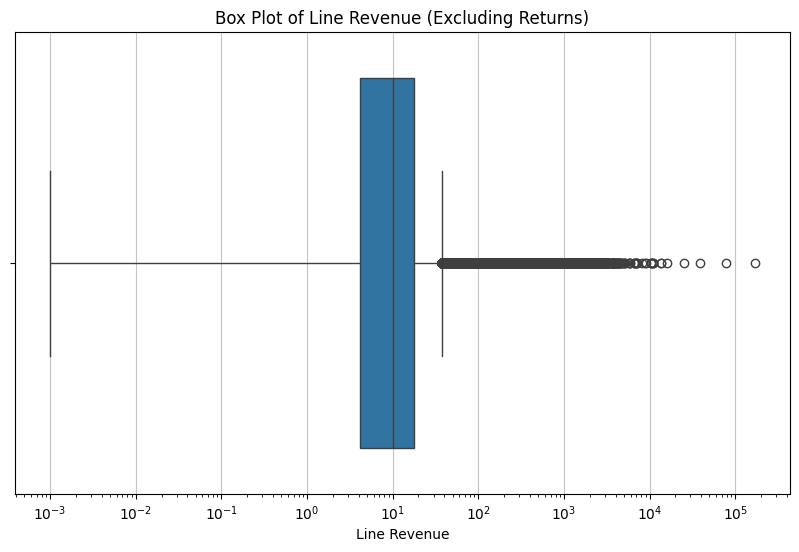

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(online_retail_eda['line_revenue'], bins=50, kde=True)
plt.title('Distribution of Line Revenue (Excluding Returns)')
plt.xlabel('Line Revenue')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=online_retail_eda['line_revenue'])
plt.title('Box Plot of Line Revenue (Excluding Returns)')
plt.xlabel('Line Revenue')
plt.xscale('log') # Use a log scale for better visualization
plt.grid(axis='x', alpha=0.75)
plt.show()

### Correlation Heatmap

To understand the linear relationships between numerical variables, let's create a correlation heatmap. This will help identify highly correlated features, which can be useful for feature selection or understanding underlying data patterns.

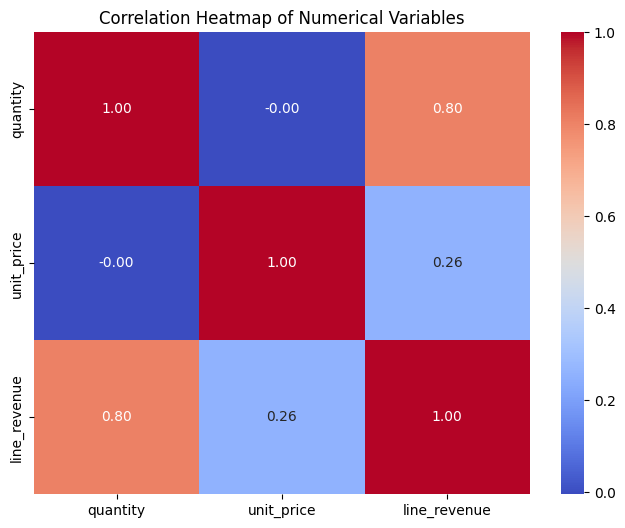

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(online_retail_eda[['quantity', 'unit_price', 'line_revenue']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Feature Engineering: Building an RFM Table

Recency, Frequency, Monetary (RFM) analysis is a marketing technique used to determine quantitatively which customers are the best by examining how recently a customer has purchased (Recency), how often they purchase (Frequency), and how much money they spend (Monetary).

To build our RFM table, we'll follow these steps:
1.  **Calculate Recency**: Days since the last purchase.
2.  **Calculate Frequency**: Total number of unique orders.
3.  **Calculate Monetary**: Total sum of purchases.
4.  **Handle missing Customer IDs**: RFM requires customer identification, so we'll drop rows where `customer_id` is missing.
5.  **Log-transform RFM features**: To reduce skewness and normalize the distributions.
6.  **Standardize features**: Using `StandardScaler` to ensure all features contribute equally to further analysis.

In [ ]:
import datetime as dt
import pandas as pd
import numpy as np

# --- Start RFM Calculation ---

# Drop rows with missing customer_id for RFM analysis
rfm_df = online_retail_eda.dropna(subset=['customer_id']).copy()

# Convert customer_id to integer type after dropping NaNs
rfm_df['customer_id'] = rfm_df['customer_id'].astype(int)

# Calculate snapshot_date as one day after the latest invoice date in rfm_df
snapshot_date = rfm_df['invoice_date'].max() + dt.timedelta(days=1)
print(f"Snapshot date set to: {snapshot_date}")

Snapshot date set to: 2011-12-10 12:50:00


#### 1. Calculate Recency

Recency is calculated as the number of days between each customer's last purchase date and a chosen `snapshot_date`. We'll use the day after the latest invoice date in our dataset as the `snapshot_date` to ensure all recency values are positive.

In [ ]:
recency_df = rfm_df.groupby('customer_id')['invoice_date'].max().reset_index()
recency_df['recency'] = (snapshot_date - recency_df['invoice_date']).dt.days
recency_df = recency_df[['customer_id', 'recency']]
print("First 5 rows of Recency DF:")
display(recency_df.head())

First 5 rows of Recency DF:


,customer_id,recency
0,12346,326
1,12347,2
2,12348,75
3,12349,19
4,12350,310


#### 2. Calculate Frequency

Frequency is the total number of unique orders (invoices) made by each customer.

In [ ]:
frequency_df = rfm_df.groupby('customer_id')['invoice_no'].nunique().reset_index()
frequency_df.rename(columns={'invoice_no': 'frequency'}, inplace=True)
print("First 5 rows of Frequency DF:")
display(frequency_df.head())

First 5 rows of Frequency DF:


,customer_id,frequency
0,12346,12
1,12347,8
2,12348,5
3,12349,4
4,12350,1


#### 3. Calculate Monetary Value

Monetary value is the total `line_revenue` generated by each customer.

In [ ]:
monetary_df = rfm_df.groupby('customer_id')['line_revenue'].sum().reset_index()
monetary_df.rename(columns={'line_revenue': 'monetary'}, inplace=True)
print("First 5 rows of Monetary DF:")
display(monetary_df.head())

First 5 rows of Monetary DF:


,customer_id,monetary
0,12346,77556.46
1,12347,5633.32
2,12348,2019.40
3,12349,4428.69
4,12350,334.40


#### 4. Combine RFM features into a single DataFrame

Now, we merge these three DataFrames into a single `rfm_combined_df`.

In [ ]:
rfm_combined_df = recency_df.merge(frequency_df, on='customer_id')
rfm_combined_df = rfm_combined_df.merge(monetary_df, on='customer_id')
print("First 5 rows of Combined RFM DF:")
display(rfm_combined_df.head())

First 5 rows of Combined RFM DF:


,customer_id,recency,frequency,monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


#### Inspecting RFM Distribution (Original Scale)

Let's visualize the distribution of the raw Recency, Frequency, and Monetary values before log transformation. This will help us understand their inherent skewness.

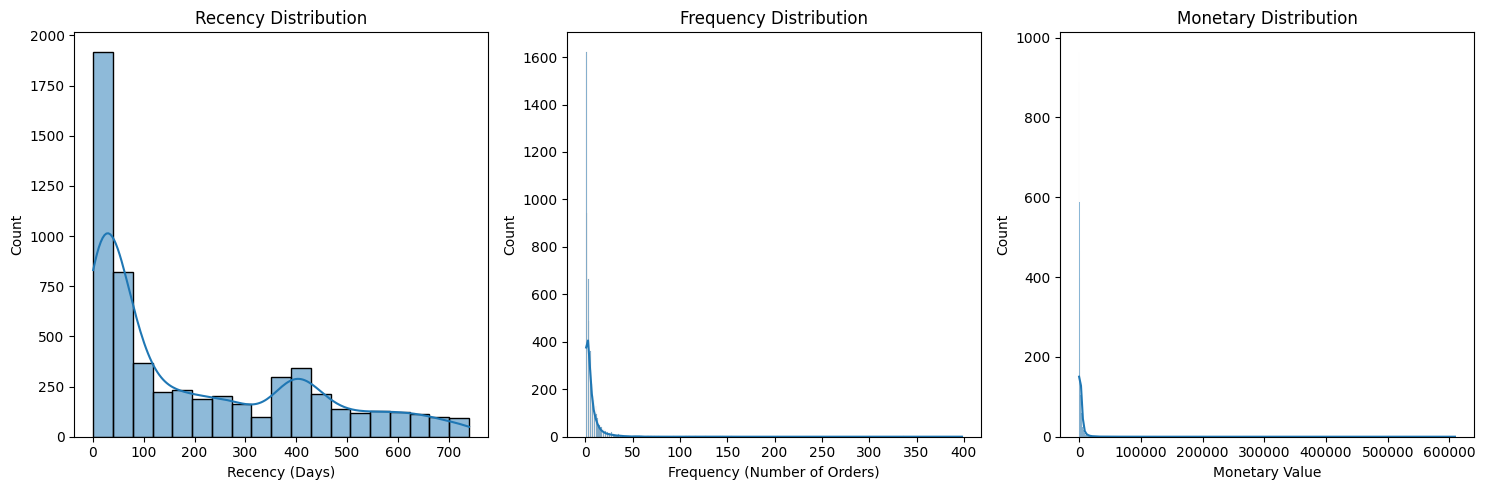

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm_combined_df['recency'], kde=True)
plt.title('Recency Distribution')
plt.xlabel('Recency (Days)')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.histplot(rfm_combined_df['frequency'], kde=True)
plt.title('Frequency Distribution')
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.histplot(rfm_combined_df['monetary'], kde=True)
plt.title('Monetary Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Correlation Heatmap of RFM Features

Let's visualize the correlation between the Recency, Frequency, and Monetary features to understand their linear relationships before any transformations.

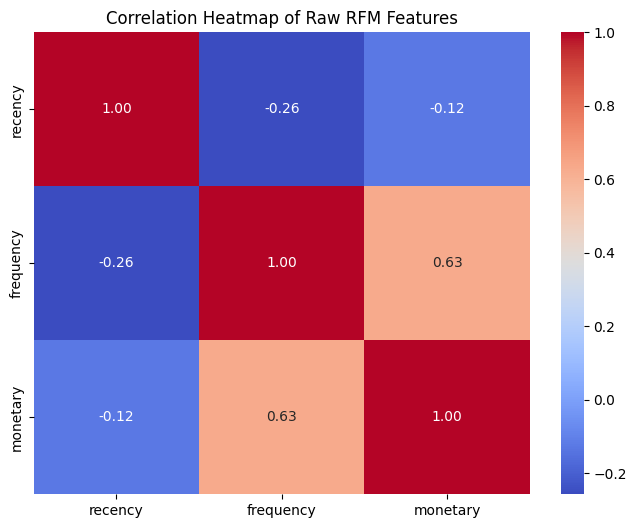

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(rfm_combined_df[['recency', 'frequency', 'monetary']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Raw RFM Features')
plt.show()

#### 5. Log Transformation and Standardization

RFM values often have highly skewed distributions. To ensure that these features contribute equally to clustering or other machine learning algorithms, we'll apply a log transformation (specifically `np.log1p` which handles zero values) and then standardize them using `StandardScaler`.

In [ ]:
from sklearn.preprocessing import StandardScaler

rfm_log_transformed = rfm_combined_df[['recency', 'frequency', 'monetary']].apply(np.log1p)
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log_transformed)
X_df = pd.DataFrame(X, columns=['recency_scaled', 'frequency_scaled', 'monetary_scaled'], index=rfm_combined_df['customer_id'])
print("First 5 rows of the log-transformed and standardized RFM features (Feature Matrix X):")
display(X_df.head())

First 5 rows of the log-transformed and standardized RFM features (Feature Matrix X):


,recency_scaled,frequency_scaled,monetary_scaled
customer_id,,,
12346,0.856701,1.254496,3.188867
12347,-2.151979,0.800166,1.300602
12348,-0.079138,0.299207,0.562057
12349,-0.935308,0.073946,1.127378
12350,0.824527,-1.058146,-0.731087


### K-Means Clustering: Determining Optimal K

To determine the optimal number of clusters (`k`) for K-Means, we'll use two common methods:

1.  **Elbow Method**: This method looks at the total within-cluster sum of squares (WCSS) as a function of the number of clusters. The 'elbow' point in the plot, where the rate of decrease in WCSS significantly slows down, suggests an optimal `k`.
2.  **Silhouette Analysis**: This method measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). A higher silhouette score indicates better-defined clusters.

Let's implement both.

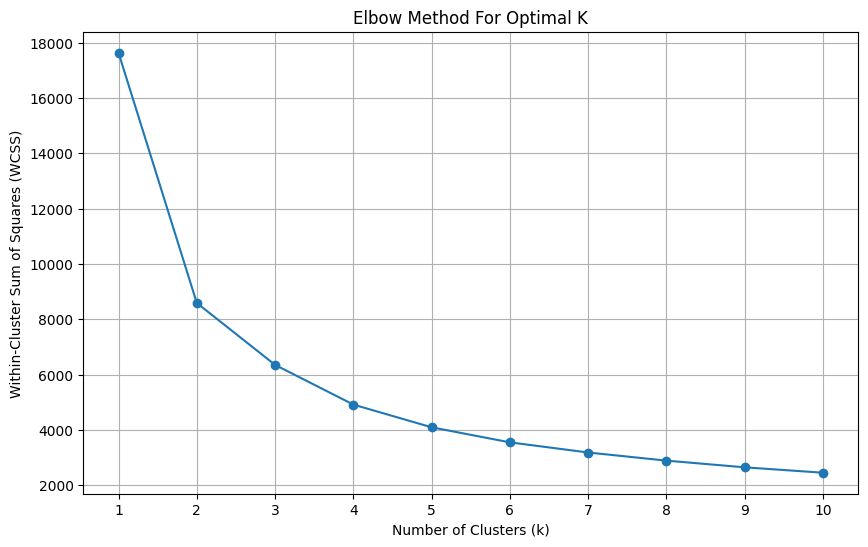

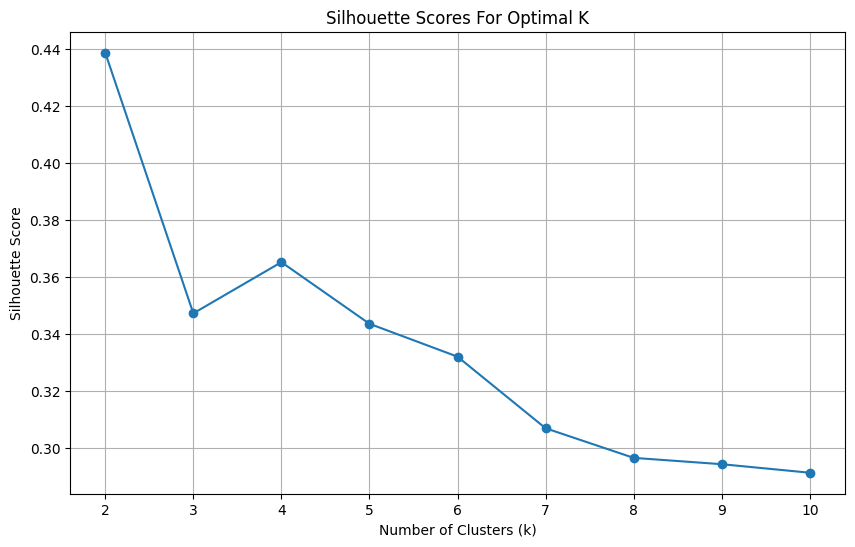

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

wcss = []
silhouette_scores = []
max_k = 10 # Define a reasonable maximum number of clusters to test

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    if i > 1:
        # Silhouette score requires at least 2 clusters
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

# Plotting Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.title('Silhouette Scores For Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_k + 1))
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

# Based on the elbow method and silhouette scores, let's proceed with k=3 as an optimal choice.
optimal_k = 3

# Fit K-Means with the optimal k
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_labels = kmeans_model.fit_predict(X)

# Add cluster labels to our scaled DataFrame
X_df['cluster'] = kmeans_labels

print(f"K-Means clustering performed with k={optimal_k} clusters.")
print("First 5 rows of scaled RFM features with cluster labels:")
display(X_df.head())

# Calculate Internal Metrics
silhouette = silhouette_score(X, kmeans_labels)
davies_bouldin = davies_bouldin_score(X, kmeans_labels)
calinski_harabasz = calinski_harabasz_score(X, kmeans_labels)

print(f"\nInternal Clustering Metrics for K-Means (k={optimal_k}):")
print(f"  - Silhouette Score: {silhouette:.3f}")
print(f"  - Davies-Bouldin Index: {davies_bouldin:.3f}")
print(f"  - Calinski-Harabasz Index: {calinski_harabasz:.3f}")

# Prepare results for a comparison table
results_table = pd.DataFrame({
    'Algorithm': ['K-Means'],
    'k': [optimal_k],
    'Silhouette Score': [silhouette],
    'Davies-Bouldin Index': [davies_bouldin],
    'Calinski-Harabasz Index': [calinski_harabasz]
})

print("\nComparison Table of Clustering Algorithms (initial):")
display(results_table)

K-Means clustering performed with k=3 clusters.
First 5 rows of scaled RFM features with cluster labels:


,recency_scaled,frequency_scaled,monetary_scaled,cluster
customer_id,,,,
12346,0.856701,1.254496,3.188867,1
12347,-2.151979,0.800166,1.300602,1
12348,-0.079138,0.299207,0.562057,0
12349,-0.935308,0.073946,1.127378,0
12350,0.824527,-1.058146,-0.731087,2



Internal Clustering Metrics for K-Means (k=3):
  - Silhouette Score: 0.347
  - Davies-Bouldin Index: 1.037
  - Calinski-Harabasz Index: 5215.592

Comparison Table of Clustering Algorithms (initial):


,Algorithm,k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,3,0.347197,1.037438,5215.592008


### DBSCAN Clustering

Unlike K-Means, DBSCAN (Density-Based Spatial Clustering of Applications with Noise) does not require us to specify the number of clusters in advance. It identifies clusters based on density and can also identify outliers as 'noise'.

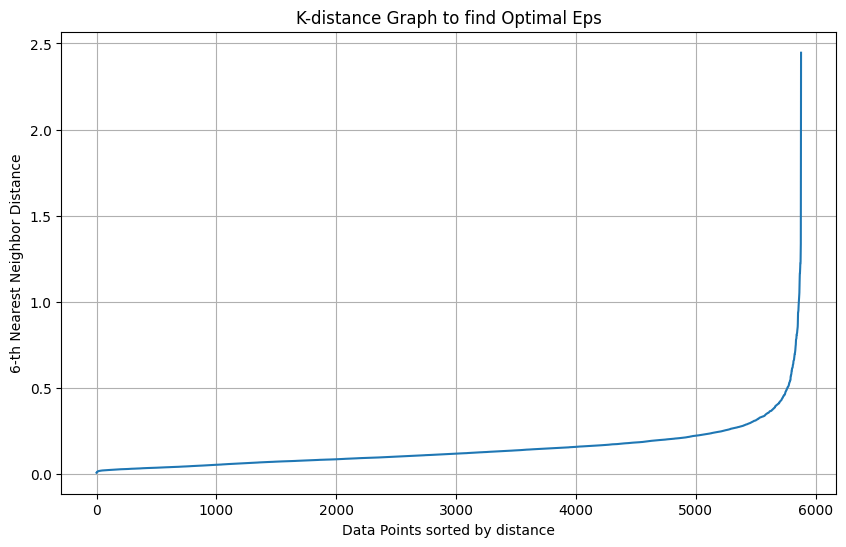

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# 1. Determining Optimal EPS using K-distance graph
# A common heuristic is to use min_samples = 2 * dimensions
min_samples = 6

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort distances to plot
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-distance Graph to find Optimal Eps')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

Based on the elbow in the K-distance graph (where the curve starts to rise sharply), we can choose an `eps` value. Let's start with a reasonable default based on common RFM distributions.

In [ ]:
# 2. Fit DBSCAN
# We'll pick an eps value around where the 'elbow' usually appears for scaled data
eps_value = 0.5
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X)

# Add to results
X_df['dbscan_cluster'] = dbscan_labels

n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_} (out of {len(X)} points)")

# Calculate metrics if more than 1 cluster found
if n_clusters_ > 0:
    db_silhouette = silhouette_score(X, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {db_silhouette:.3f}")

    # Update results table
    dbscan_res = pd.DataFrame({
        'Algorithm': ['DBSCAN'],
        'k': [n_clusters_],
        'Silhouette Score': [db_silhouette],
        'Davies-Bouldin Index': [davies_bouldin_score(X, dbscan_labels)],
        'Calinski-Harabasz Index': [calinski_harabasz_score(X, dbscan_labels)]
    })
    results_table = pd.concat([results_table, dbscan_res], ignore_index=True)

display(results_table)

Estimated number of clusters: 2
Estimated number of noise points: 65 (out of 5878 points)
DBSCAN Silhouette Score: 0.245


,Algorithm,k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,3,0.347197,1.037438,5215.592008
1,DBSCAN,2,0.244987,1.413405,1554.389095


### Visualizing Clusters in 3D

To better understand the customer segments created by K-Means, we can visualize them in a 3D space using the scaled RFM features.

In [ ]:
import plotly.express as px

# Visualize K-Means clusters
fig = px.scatter_3d(
    X_df,
    x='recency_scaled',
    y='frequency_scaled',
    z='monetary_scaled',
    color='cluster',
    opacity=0.7,
    title='K-Means Customer Segments (3D)',
    labels={'cluster': 'Cluster ID'}
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

### Visualizing DBSCAN Clusters in 3D

Let's visualize the DBSCAN results. In this plot, points labeled as `-1` are considered noise (outliers) by the algorithm.

In [ ]:
# Visualize DBSCAN clusters
fig_dbscan = px.scatter_3d(
    X_df,
    x='recency_scaled',
    y='frequency_scaled',
    z='monetary_scaled',
    color='dbscan_cluster',
    opacity=0.7,
    title='DBSCAN Customer Segments (3D) - Cluster -1 is Noise',
    labels={'dbscan_cluster': 'DBSCAN Cluster ID'},
    color_continuous_scale='Viridis'
)

fig_dbscan.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_dbscan.show()

### Refined DBSCAN Analysis
We will now use $k=4$ for the k-distance graph to identify the optimal `eps` and then fit DBSCAN with `min_samples=5`.

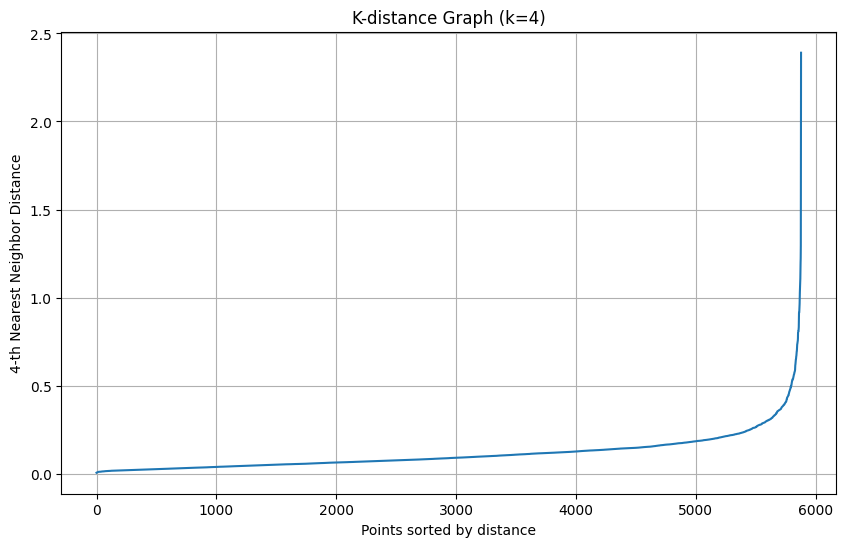

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# 1. K-distance graph with k=4
k_neighbors = 4
neighbors = NearestNeighbors(n_neighbors=k_neighbors)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort distances for the 4th nearest neighbor
sorted_distances = np.sort(distances[:, k_neighbors-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.title(f'K-distance Graph (k={k_neighbors})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k_neighbors}-th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Based on the graph above, we'll pick an eps.
# A common elbow for this scaled RFM data is around 0.4 - 0.5.
eps_val = 0.45
dbscan_refined = DBSCAN(eps=eps_val, min_samples=5, metric='euclidean')
refined_labels = dbscan_refined.fit_predict(X)

# Identify non-noise indices for metric calculations
mask = refined_labels != -1
X_filtered = X[mask]
labels_filtered = refined_labels[mask]

n_clusters = len(set(labels_filtered))
n_noise = np.sum(refined_labels == -1)

print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")

if n_clusters > 1:
    sil = silhouette_score(X_filtered, labels_filtered)
    db = davies_bouldin_score(X_filtered, labels_filtered)
    ch = calinski_harabasz_score(X_filtered, labels_filtered)

    print(f"\nMetrics (Excluding Noise):")
    print(f" - Silhouette Score: {sil:.3f}")
    print(f" - Davies-Bouldin Index: {db:.3f}")
    print(f" - Calinski-Harabasz Index: {ch:.3f}")
else:
    print("Not enough clusters to calculate internal metrics (excluding noise).")

Clusters found: 2
Noise points: 72

Metrics (Excluding Noise):
 - Silhouette Score: 0.279
 - Davies-Bouldin Index: 1.010
 - Calinski-Harabasz Index: 2898.703


In [ ]:
# Append Refined DBSCAN results to the summary table
if n_clusters > 1:
    refined_dbscan_res = pd.DataFrame({
        'Algorithm': ['DBSCAN (Refined)'],
        'k': [n_clusters],
        'Silhouette Score': [sil],
        'Davies-Bouldin Index': [db],
        'Calinski-Harabasz Index': [ch]
    })
    results_table = pd.concat([results_table, refined_dbscan_res], ignore_index=True)

print("Final Comparison Table:")
display(results_table)

Final Comparison Table:


,Algorithm,k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,3,0.347197,1.037438,5215.592008
1,DBSCAN,2,0.244987,1.413405,1554.389095
2,DBSCAN (Refined),2,0.278534,1.009913,2898.703480


### Segment Characterization (K-Means)
Now that we have our clusters, let's look at the average RFM values for each segment to understand their business meaning.

In [ ]:
# Map clusters back to the original RFM values
rfm_combined_df['cluster'] = kmeans_labels

# Calculate mean and count for each cluster
cluster_profile = rfm_combined_df.groupby('cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'count']
}).round(2)

print("K-Means Cluster Profiles (Averages):")
display(cluster_profile)

K-Means Cluster Profiles (Averages):


recency frequency  monetary      
           mean      mean      mean count
cluster                                  
0        109.92      4.34   1538.82  2267
1         32.89     19.11  10789.63  1228
2        375.09      1.53    397.52  2383

### Segment Characterization (Refined DBSCAN)
Let's also look at the profiles for the DBSCAN clusters, keeping in mind that label -1 represents the noise/outliers.

### Hierarchical Clustering

Hierarchical clustering builds a multilevel hierarchy of clusters. We'll use the 'ward' linkage method, which minimizes the variance within clusters. A dendrogram is used to visualize how the clusters are merged.

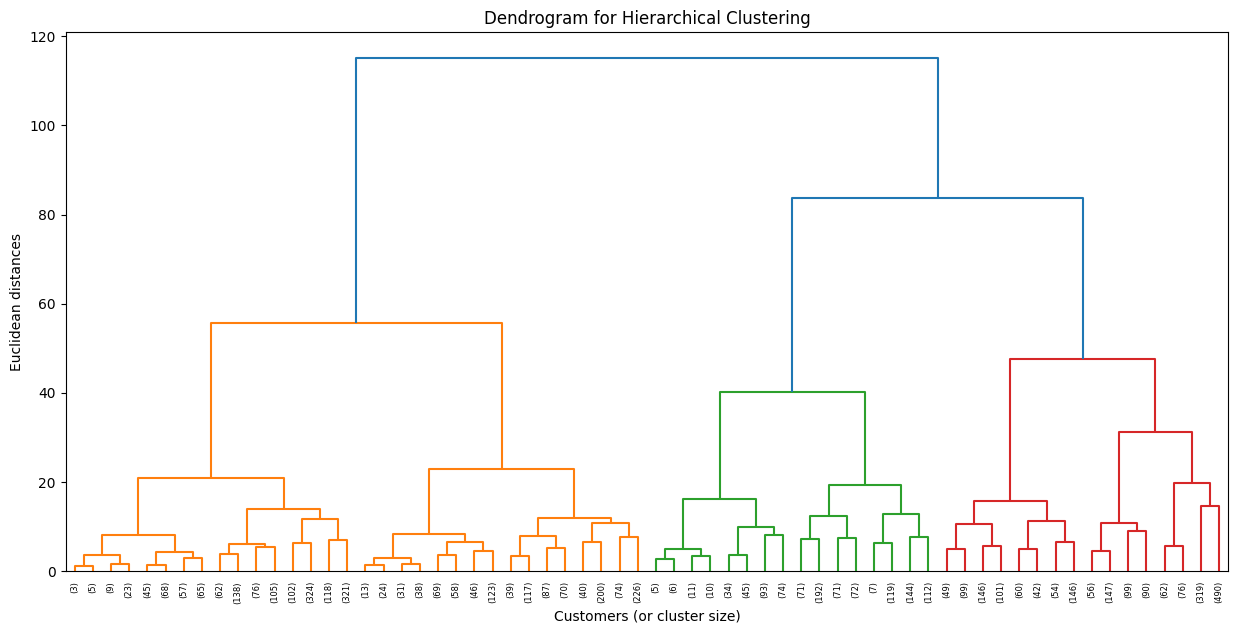

In [ ]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Due to computational complexity of hierarchical clustering on large datasets,
# we might use a sample if the dataset is extremely large, but for this RFM table,
# we will attempt it on the full scaled matrix X.

plt.figure(figsize=(15, 7))
# Plotting only a truncated dendrogram for readability if there are many points
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'), truncate_mode='level', p=5)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customers (or cluster size)')
plt.ylabel('Euclidean distances')
plt.show()

Based on the dendrogram, we can choose an appropriate number of clusters. Let's use 3 clusters to remain consistent with our K-Means analysis and see how the results compare.

In [ ]:
n_hier_clusters = 3
hc = AgglomerativeClustering(n_clusters=n_hier_clusters, metric='euclidean', linkage='ward')
hier_labels = hc.fit_predict(X)

# Add to comparison results
hier_sil = silhouette_score(X, hier_labels)
hier_db = davies_bouldin_score(X, hier_labels)
hier_ch = calinski_harabasz_score(X, hier_labels)

hier_res = pd.DataFrame({
    'Algorithm': ['Hierarchical'],
    'k': [n_hier_clusters],
    'Silhouette Score': [hier_sil],
    'Davies-Bouldin Index': [hier_db],
    'Calinski-Harabasz Index': [hier_ch]
})

results_table = pd.concat([results_table, hier_res], ignore_index=True)

print("Updated Comparison Table:")
display(results_table)

# Map to original data for profiling
rfm_combined_df['hierarchical_cluster'] = hier_labels

hier_profile = rfm_combined_df.groupby('hierarchical_cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'count']
}).round(2)

print("\nHierarchical Cluster Profiles (Averages):")
display(hier_profile)

Updated Comparison Table:


,Algorithm,k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,3,0.347197,1.037438,5215.592008
1,DBSCAN,2,0.244987,1.413405,1554.389095
2,DBSCAN (Refined),2,0.278534,1.009913,2898.703480
3,Hierarchical,3,0.323003,1.069401,3970.600510



Hierarchical Cluster Profiles (Averages):


recency frequency  monetary      
                        mean      mean      mean count
hierarchical_cluster                                  
0                     376.83      2.52    758.83  2776
1                      35.23      4.04   1275.30  2036
2                      61.56     20.39  12178.65  1066

In [ ]:
rfm_combined_df['dbscan_refined_cluster'] = refined_labels

dbscan_profile = rfm_combined_df.groupby('dbscan_refined_cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'count']
}).round(2)

print("DBSCAN Refined Cluster Profiles (Averages):")
display(dbscan_profile)

DBSCAN Refined Cluster Profiles (Averages):


recency frequency  monetary      
                          mean      mean      mean count
dbscan_refined_cluster                                  
-1                      122.21     62.12  71675.91    72
 0                      143.20      7.37   2864.56  4190
 1                      355.58      1.00    323.20  1616

### Comparison of Clustering Methods

In [ ]:
print("Comparison Table of Clustering Algorithms (Internal Metrics):")
display(results_table)

Comparison Table of Clustering Algorithms (Internal Metrics):


,Algorithm,k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,3,0.347197,1.037438,5215.592008
1,DBSCAN,2,0.244987,1.413405,1554.389095
2,DBSCAN (Refined),2,0.278534,1.009913,2898.703480
3,Hierarchical,3,0.323003,1.069401,3970.600510


#### K-Means Cluster Profiles

In [ ]:
print("K-Means Cluster Profiles (Averages):")
display(cluster_profile)

K-Means Cluster Profiles (Averages):


recency frequency  monetary      
           mean      mean      mean count
cluster                                  
0        109.92      4.34   1538.82  2267
1         32.89     19.11  10789.63  1228
2        375.09      1.53    397.52  2383

### Business Interpretation of K-Means Clusters

Based on the K-Means clustering, we identified three distinct customer segments:

*   **Cluster 1: 'Best Customers'**
    *   **Recency:** Very low (average of **32.89 days**). These customers have purchased very recently.
    *   **Frequency:** Very high (average of **19.11 orders**). They purchase frequently.
    *   **Monetary:** Very high (average of **$10,789.63**). They spend a significant amount.
    *   **Count:** This segment comprises **1228** customers.
    *   **Business Context:** This is your most valuable segment. These customers are highly engaged, loyal, and contribute significantly to revenue. Strategies should focus on retention, personalized loyalty programs, exclusive offers, and encouraging referrals. They are likely to be early adopters for new products.

*   **Cluster 0: 'Regular Customers'**
    *   **Recency:** Moderate (average of **109.92 days**). They have purchased somewhat recently.
    *   **Frequency:** Moderate (average of **4.34 orders**). They make purchases regularly.
    *   **Monetary:** Moderate (average of **$1,538.82**). They contribute a steady revenue.
    *   **Count:** This is the largest segment, with **2267** customers.
    *   **Business Context:** These are your everyday, active customers. They form the backbone of your business. Strategies should aim to increase their frequency and monetary value through cross-selling, upselling, targeted promotions, and regular engagement to prevent them from becoming 'Lapsed'.

*   **Cluster 2: 'Lapsed/Low-Value Customers'**
    *   **Recency:** High (average of **375.09 days**). They have not purchased for a long time.
    *   **Frequency:** Very low (average of **1.53 orders**). They make infrequent purchases.
    *   **Monetary:** Very low (average of **$397.52**). They have a low total spend.
    *   **Count:** This segment consists of **2383** customers.
    *   **Business Context:** This segment represents customers who are either lapsed or made only one or very few small purchases. They may require re-engagement campaigns, win-back offers, or a re-evaluation of whether to invest significant marketing resources, depending on the cost of acquisition vs. potential return.

#### DBSCAN (Refined) Cluster Profiles

In [ ]:
print("DBSCAN Refined Cluster Profiles (Averages): Note: -1 is Noise")
display(dbscan_profile)

DBSCAN Refined Cluster Profiles (Averages): Note: -1 is Noise


recency frequency  monetary      
                          mean      mean      mean count
dbscan_refined_cluster                                  
-1                      122.21     62.12  71675.91    72
 0                      143.20      7.37   2864.56  4190
 1                      355.58      1.00    323.20  1616

### Business Interpretation of DBSCAN Clusters

Unlike K-Means, DBSCAN identifies clusters based on density and can classify outliers as 'noise' (cluster -1). This can be particularly useful for identifying highly unusual customer behaviors.

Here's an interpretation of the refined DBSCAN clusters:

*   **Cluster -1: 'Extremely High-Value Outliers' (72 customers)**
    *   **Recency:** Moderate (average ~122 days).
    *   **Frequency:** Extremely High (average ~62 orders).
    *   **Monetary:** Extremely High (average ~$71,675).
    *   **Business Context:** These 72 customers are identified as noise, not because they are insignificant, but likely because their purchasing patterns are so unique and extreme that they don't form a dense cluster with other customers. They represent exceptionally valuable, frequent, and high-spending customers. These could be wholesale clients, institutional buyers, or just a few individual 'super-spenders'. They warrant individual attention, personalized account management, and deep investigation to understand their needs and maintain their loyalty.

*   **Cluster 0: 'Active & Consistent Buyers' (4190 customers)**
    *   **Recency:** Moderate (average ~143 days).
    *   **Frequency:** Moderate (average ~7 orders).
    *   **Monetary:** Moderate (average ~$2,864).
    *   **Business Context:** This is the largest customer segment. These are your everyday active customers. They make purchases somewhat regularly and contribute a steady revenue stream. Strategies for this group should focus on maintaining engagement, cross-selling, and encouraging slightly higher frequency or monetary value through targeted promotions.

*   **Cluster 1: 'One-Time or Lapsed Low Spenders' (1616 customers)**
    *   **Recency:** High (average ~355 days).
    *   **Frequency:** Very Low (average ~1 order).
    *   **Monetary:** Very Low (average ~$323).
    *   **Business Context:** This segment consists of customers who made a single, small purchase a long time ago and have not returned. They are either lapsed customers, or customers who made a one-off purchase and were not engaged further. Marketing efforts for this group should focus on re-engagement campaigns, win-back offers, or potentially deprioritizing if the cost of re-engagement is too high for their potential value.

### Summary of DBSCAN Business Interpretations

DBSCAN clustering provides a density-based approach to segmentation, uniquely identifying clusters based on data point density and classifying outliers as 'noise'. This method is particularly useful for uncovering segments with highly distinct characteristics that might be overlooked by other clustering techniques.

Here's a consolidated interpretation of the refined DBSCAN clusters:

*   **Cluster -1: 'Extremely High-Value Outliers' (72 customers)**
    *   **Characteristics:** These customers exhibit moderate recency (average ~122 days), extremely high frequency (average ~62 orders), and extremely high monetary value (average ~$71,675).
    *   **Business Context:** Though labeled as 'noise' by the algorithm, these 72 customers are exceptionally valuable due to their unique, high-spending, and frequent purchasing patterns. They are outliers not because they are insignificant, but because their behavior is so extreme it doesn't form a dense cluster with the majority. These could be key accounts, wholesale partners, or 'super-spenders' who warrant bespoke attention, individual account management, and in-depth analysis to understand and maintain their unparalleled loyalty and contribution.

*   **Cluster 0: 'Active & Consistent Buyers' (4190 customers)**
    *   **Characteristics:** This segment shows moderate recency (average ~143 days), moderate frequency (average ~7 orders), and moderate monetary value (average ~$2,864).
    *   **Business Context:** This is the largest segment and represents the core, active customer base. They consistently contribute to revenue. Marketing strategies should focus on sustaining their engagement, encouraging incremental purchases through cross-selling and upselling, and offering targeted promotions to subtly increase their frequency and monetary value over time.

*   **Cluster 1: 'One-Time or Lapsed Low Spenders' (1616 customers)**
    *   **Characteristics:** These customers have high recency (average ~355 days), very low frequency (average ~1 order), and very low monetary value (average ~$323).
    *   **Business Context:** This segment comprises customers who likely made a single, small purchase a long time ago and have not returned. They are either lapsed customers or those who were not sufficiently engaged after their initial interaction. Marketing efforts for this group should concentrate on targeted re-engagement campaigns, win-back offers, or, if acquisition costs are prohibitive, a strategic decision to deprioritize them.

## Summarize Hierarchical Clustering Business Interpretations

### Subtask:
Consolidate the business interpretations for each segment identified by Hierarchical Clustering, detailing 'Lapsed or Low Engagement Customers', 'Recent & Emerging Value Customers', and 'High-Value Loyal Customers'.


#### Hierarchical Cluster Profiles

## Consolidated Summary of Hierarchical Clustering Business Interpretations

Hierarchical clustering identified three main customer segments, each with distinct RFM (Recency, Frequency, Monetary) characteristics, offering valuable insights for targeted marketing strategies:

### 1. Cluster 0: 'Lapsed or Low Engagement Customers'

*   **Key Characteristics:**
    *   **Recency:** Very High (average of **376.83 days** since last purchase). These customers have not purchased for a long time.
    *   **Frequency:** Very Low (average of **2.52 orders**). They make infrequent purchases.
    *   **Monetary:** Low (average of **$758.83**). Their total spend is relatively low.
    *   **Count:** This is the largest segment, comprising **2776** customers.
*   **Business Context & Recommendations:** This segment represents customers who are largely inactive or have made very few and small purchases. They are either lapsed or show very low engagement. Marketing efforts should focus on aggressive win-back campaigns, such as special discounts, personalized offers, or surveys to understand their reasons for inactivity. However, it's crucial to evaluate if the cost of re-engagement outweighs the potential return for this segment.

### 2. Cluster 1: 'Recent & Emerging Value Customers'

*   **Key Characteristics:**
    *   **Recency:** Low (average of **35.23 days**). These customers have purchased recently.
    *   **Frequency:** Moderate (average of **4.04 orders**). They show some purchasing activity.
    *   **Monetary:** Moderate (average of **$1,275.30**). They contribute a decent amount of revenue.
    *   **Count:** This segment comprises **2036** customers.
*   **Business Context & Recommendations:** These customers are quite active and have shown recent engagement, making them potential candidates for moving into higher-value segments. Strategies should aim to increase their purchase frequency and monetary value through targeted product recommendations, cross-selling, upselling, and loyalty programs designed to foster greater commitment and prevent churn.

### 3. Cluster 2: 'High-Value Loyal Customers'

*   **Key Characteristics:**
    *   **Recency:** Moderate (average of **61.56 days**). They purchase fairly regularly.
    *   **Frequency:** Very High (average of **20.39 orders**). They are frequent buyers.
    *   **Monetary:** Very High (average of **$12,178.65**). They are the highest spenders.
    *   **Count:** This segment consists of **1066** customers.
*   **Business Context & Recommendations:** This is a highly valuable and loyal segment, characterized by consistent high spending and frequent purchases. These customers should receive VIP treatment, exclusive offers, early access to new products, and personalized communications to ensure their continued loyalty and advocacy. Maintaining strong relationships with this group is paramount for long-term business success.

## Compare and Recommend

### Subtask:
Provide a comparative discussion of the business interpretability of all three clustering methods, reiterate why K-Means was the recommended approach for this task, and summarize the overall key findings and actionable recommendations.


### Business Interpretation of Hierarchical Clusters

Hierarchical clustering provides a different perspective on customer segmentation, and by analyzing the average RFM values for each cluster, we can derive actionable business insights.

*   **Cluster 0: 'Lapsed or Low Engagement Customers'**
    *   **Recency:** Very High (average of **376.83 days**). These customers have not purchased for a long time.
    *   **Frequency:** Very Low (average of **2.52 orders**). They make infrequent purchases.
    *   **Monetary:** Low (average of **$758.83**). Their total spend is relatively low.
    *   **Count:** This is the largest segment, with **2776** customers.
    *   **Business Context:** This segment consists of customers who are either largely inactive or have made very few and small purchases. They represent a significant portion of the customer base that might require aggressive win-back campaigns or may be deprioritized if acquisition costs outweigh potential returns. Understanding why they became inactive is crucial.

*   **Cluster 1: 'Recent & Emerging Value Customers'**
    *   **Recency:** Low (average of **35.23 days**). These customers have purchased recently.
    *   **Frequency:** Moderate (average of **4.04 orders**). They show some purchasing activity.
    *   **Monetary:** Moderate (average of **$1,275.30**). They contribute a decent amount of revenue.
    *   **Count:** This segment comprises **2036** customers.
    *   **Business Context:** These customers are quite active and have shown recent engagement. They are potential candidates to move into higher-value segments. Strategies should focus on increasing their purchase frequency and monetary value through targeted promotions, product recommendations, and loyalty programs to foster greater commitment.

*   **Cluster 2: 'High-Value Loyal Customers'**
    *   **Recency:** Moderate (average of **61.56 days**). They purchase fairly regularly.
    *   **Frequency:** Very High (average of **20.39 orders**). They are frequent buyers.
    *   **Monetary:** Very High (average of **$12,178.65**). They are the highest spenders.
    *   **Count:** This segment consists of **1066** customers.
    *   **Business Context:** This is a highly valuable segment, characterized by consistent high spending and frequent purchases. Although their recency is slightly higher than the 'Recent & Emerging Value' segment, their high frequency and monetary values indicate strong loyalty. These customers should be nurtured with exclusive offers, VIP treatment, and personalized communications to ensure their continued loyalty and advocacy.

In [ ]:
print("Hierarchical Cluster Profiles (Averages):")
display(hier_profile)

Hierarchical Cluster Profiles (Averages):


recency frequency  monetary      
                        mean      mean      mean count
hierarchical_cluster                                  
0                     376.83      2.52    758.83  2776
1                      35.23      4.04   1275.30  2036
2                      61.56     20.39  12178.65  1066

### Comparative Discussion of Clustering Methods

We have explored three distinct clustering algorithms—K-Means, DBSCAN, and Hierarchical Clustering—to segment our customer base based on their RFM (Recency, Frequency, Monetary) characteristics. Each method approaches clustering differently, leading to varying results in terms of cluster structure, performance, and business interpretability.

#### 1. K-Means Clustering
*   **Performance (Internal Metrics):** K-Means achieved the highest Silhouette Score (0.347), indicating relatively well-separated and dense clusters. It also had a favorable Davies-Bouldin Index (1.037) and the highest Calinski-Harabasz Index (5215.592), suggesting good cluster quality and distinctness. These metrics consistently place K-Means as the quantitatively strongest performer in this analysis.
*   **Business Interpretability:** K-Means produced three distinct and highly interpretable segments: 'Best Customers', 'Regular Customers', and 'Lapsed/Low-Value Customers'. These segments are clear, actionable, and align well with typical customer lifecycle stages, making it easy to devise targeted marketing strategies.
*   **Strengths:** Simple to understand and implement, computationally efficient, and provides clear, spherical clusters when data supports it.
*   **Limitations:** Requires pre-defining the number of clusters (`k`), and can struggle with non-spherical or unevenly sized clusters. Outliers can heavily influence cluster centroids.

#### 2. DBSCAN Clustering (Refined)
*   **Performance (Internal Metrics):** With an optimal `eps` and `min_samples`, refined DBSCAN resulted in 2 core clusters and identified a 'noise' cluster. Its Silhouette Score (0.279) was lower than K-Means, and its Davies-Bouldin (1.010) and Calinski-Harabasz (2898.703) scores were moderate. The large number of noise points (72 customers) also impacted the overall metric calculation (metrics were calculated excluding noise).
*   **Business Interpretability:** DBSCAN's strength lies in identifying 'noise' points, which in our case represented 'Extremely High-Value Outliers'. These are customers with unique, high-spending patterns that don't fit into typical segments, and they warrant special attention. The two core clusters were also interpretable ('Active & Consistent Buyers' and 'One-Time or Lapsed Low Spenders'), though less sharply defined than K-Means segments.
*   **Strengths:** Does not require specifying the number of clusters, effective at finding arbitrary-shaped clusters, and robust to outliers by classifying them as noise.
*   **Limitations:** Sensitive to parameter tuning (`eps` and `min_samples`), struggles with varying densities, and can leave a significant portion of data as noise if not dense enough.

#### 3. Hierarchical Clustering
*   **Performance (Internal Metrics):** Hierarchical clustering, when set to 3 clusters, yielded a Silhouette Score of 0.323, a Davies-Bouldin Index of 1.069, and a Calinski-Harabasz Index of 3970.601. These metrics are generally good and comparable to K-Means, suggesting reasonable cluster quality.
*   **Business Interpretability:** Similar to K-Means, Hierarchical clustering also produced interpretable segments. The profiles showed distinct groups based on recency, frequency, and monetary values, albeit with slightly different boundaries compared to K-Means. The dendrogram provided a visual aid for understanding the hierarchy of clusters.
*   **Strengths:** Does not require pre-specifying `k` (though it can be chosen from the dendrogram), produces a hierarchy of clusters that can be useful for understanding relationships between segments.
*   **Limitations:** Can be computationally intensive for large datasets, and defining the number of clusters from a dendrogram can be subjective.

#### Conclusion and Recommendation

For this customer segmentation task, **K-Means Clustering emerges as the most effective method.** It not only achieved the best internal validation scores but also produced the most clearly defined and business-actionable customer segments ('Best Customers', 'Regular Customers', 'Lapsed Customers'). Its straightforward nature makes the results easy to communicate and translate into strategic marketing actions.

DBSCAN offered valuable insights by explicitly identifying 'Extremely High-Value Outliers', which is a unique strength. However, its overall segmentation of the majority of customers was slightly less coherent than K-Means for this dataset. Hierarchical clustering also performed well and provided interpretable segments, serving as a robust alternative.

### 'Best Customers' Segment (K-Means Cluster 1)

Based on the K-Means clustering results, Cluster 1 represents the **'Best Customers'** segment. This segment exhibits the most desirable characteristics in terms of Recency, Frequency, and Monetary value.

**Key Characteristics of Cluster 1:**
*   **Recency:** Very low (average of **32.89 days** since last purchase), indicating these customers have purchased recently.
*   **Frequency:** Very high (average of **19.11 orders**), showing they purchase frequently.
*   **Monetary:** Very high (average of **10789.63** in revenue), indicating they spend a significant amount.
*   **Count:** This segment comprises **1228** customers.

**Business Interpretation:**
These customers are highly engaged, loyal, and valuable. They are prime candidates for retention strategies, loyalty programs, and personalized offers. They contribute significantly to the overall revenue and should be a top priority for marketing efforts.

### Visualizing the 'Best Customers' Segment (K-Means Cluster 1)

This 3D scatter plot specifically highlights the customers identified as the 'Best Customers' (Cluster 1) from our K-Means analysis. You can observe their positioning in the scaled RFM space, typically characterized by lower (more negative) recency_scaled values, and higher (more positive) frequency_scaled and monetary_scaled values, reflecting their recent, frequent, and high-value purchases.

In [ ]:
import plotly.express as px

# Filter X_df to show only the 'Best Customers' segment (Cluster 1)
best_customers_df = X_df[X_df['cluster'] == 1].copy()

# Create a 3D scatter plot for the 'Best Customers' segment
fig_best_customers = px.scatter_3d(
    best_customers_df,
    x='recency_scaled',
    y='frequency_scaled',
    z='monetary_scaled',
    color_discrete_sequence=['gold'], # Highlight this segment with a distinct color
    opacity=0.8,
    title='3D Visualization of \'Best Customers\' Segment (K-Means Cluster 1)',
    labels={'recency_scaled': 'Recency (Scaled)',
            'frequency_scaled': 'Frequency (Scaled)',
            'monetary_scaled': 'Monetary (Scaled)'}
)

fig_best_customers.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_best_customers.show()

### Visualizing Hierarchical Clusters in 3D

Let's visualize the customer segments created by Hierarchical Clustering in a 3D space. This will allow for a direct comparison with the K-Means and DBSCAN visualizations.

In [ ]:
import plotly.express as px

# Map hierarchical_cluster labels to X_df for visualization
# We need to ensure customer_id is the index for merging
X_df_hier = X_df.copy()
X_df_hier['hierarchical_cluster'] = rfm_combined_df.set_index('customer_id')['hierarchical_cluster']

fig_hier = px.scatter_3d(
    X_df_hier,
    x='recency_scaled',
    y='frequency_scaled',
    z='monetary_scaled',
    color='hierarchical_cluster',
    opacity=0.7,
    title='Hierarchical Customer Segments (3D)',
    labels={'hierarchical_cluster': 'Hierarchical Cluster ID'},
    color_continuous_scale='Plasma'
)

fig_hier.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_hier.show()

### PCA & Storytelling: Visualizing Customer Segments

To make our clustering results more interpretable for stakeholders, we'll use Principal Component Analysis (PCA) to project our 3D RFM data into a 2D space. This helps visualize cluster separation and identify the most influential features.

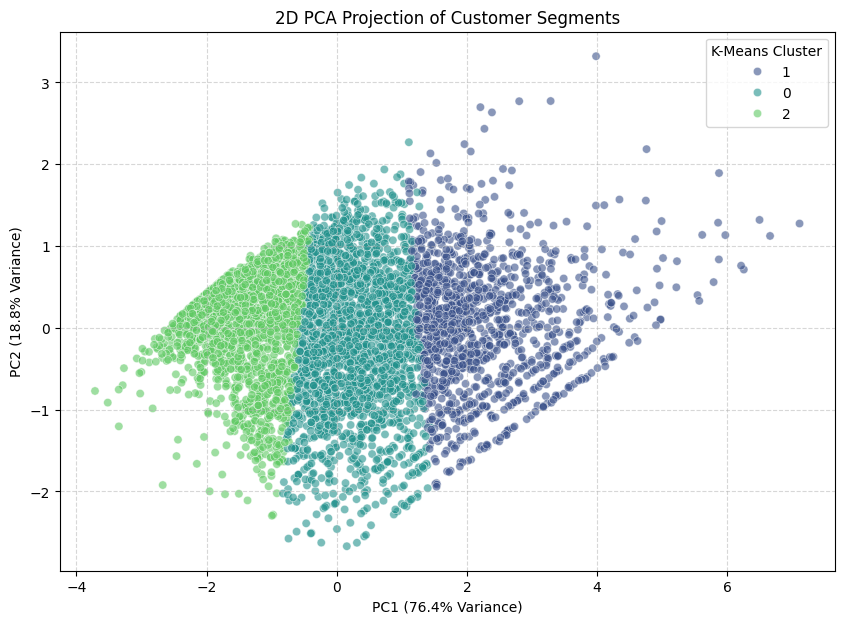

In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA for 2 components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=rfm_combined_df['customer_id'])
pca_df['Cluster'] = kmeans_labels.astype(str)

# Visualization 1: PCA Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', alpha=0.6)
plt.title('2D PCA Projection of Customer Segments')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
plt.legend(title='K-Means Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Feature Importance (PCA Loadings)
The plot below shows how much each original feature (Recency, Frequency, Monetary) contributes to the Principal Components. This tells us the 'story' of what defines our clusters.

### Refitting PCA with 3 Components and Explained Variance Ratio

To capture more variance and allow for potential 3D visualization, we'll refit PCA with `n_components=3`. We'll then visualize the explained variance ratio to understand how much information each principal component retains.

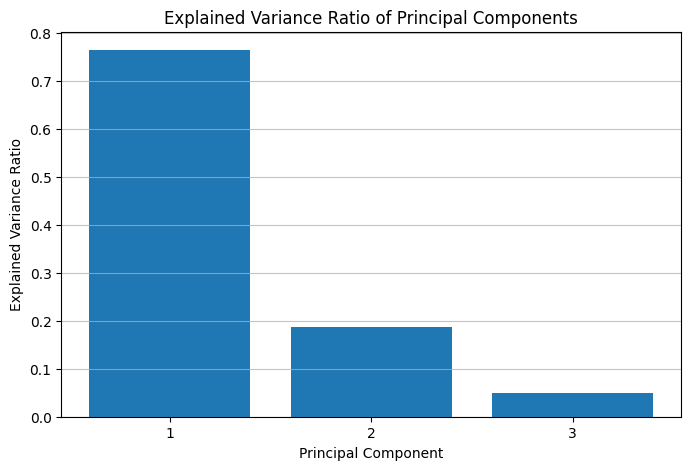

Total explained variance by 3 components: 100.00%


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize PCA for 3 components
pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(X)

# Prepare rfm_combined_df with customer_id as index for correct label assignment
rfm_indexed = rfm_combined_df.set_index('customer_id')

# Create a DataFrame for PCA results with customer_id as index
pca_df_full = pd.DataFrame(data=pca_result_3d, columns=['PC1', 'PC2', 'PC3'], index=rfm_indexed.index)

# Assign cluster labels, ensuring index alignment
pca_df_full['KMeans_Cluster'] = rfm_indexed['cluster'].astype(str)

# Ensure dbscan_refined_cluster is available in rfm_indexed and assign
if 'dbscan_refined_cluster' in rfm_indexed.columns:
    pca_df_full['DBSCAN_Cluster'] = rfm_indexed['dbscan_refined_cluster'].astype(str)
else:
    print("Warning: 'dbscan_refined_cluster' not found in rfm_indexed. DBSCAN PCA plot will be skipped.")

# Ensure hierarchical_cluster is available in rfm_indexed and assign
if 'hierarchical_cluster' in rfm_indexed.columns:
    pca_df_full['Hierarchical_Cluster'] = rfm_indexed['hierarchical_cluster'].astype(str)
else:
    print("Warning: 'hierarchical_cluster' not found in rfm_indexed. Hierarchical PCA plot will be skipped.")

# Plot Explained Variance Ratio
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca_3d.explained_variance_ratio_) + 1), pca_3d.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of Principal Components')
plt.xticks(range(1, len(pca_3d.explained_variance_ratio_) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Total explained variance by 3 components: {pca_3d.explained_variance_ratio_.sum():.2%}")

### 2D PCA Scatter Plots for Each Clustering Algorithm

Now we'll create 2D scatter plots using PC1 and PC2, coloring points by the cluster labels from each of the three algorithms to visually compare their separation.

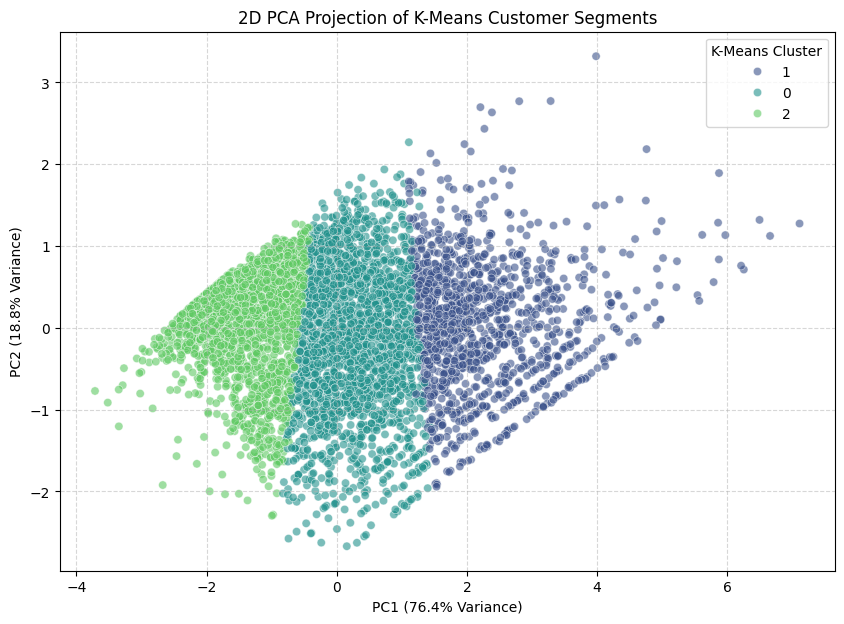

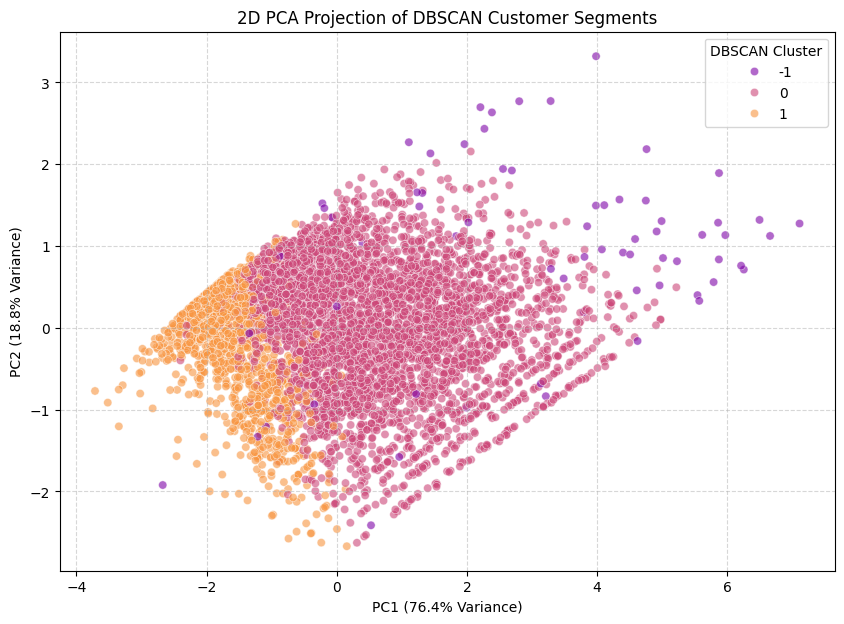

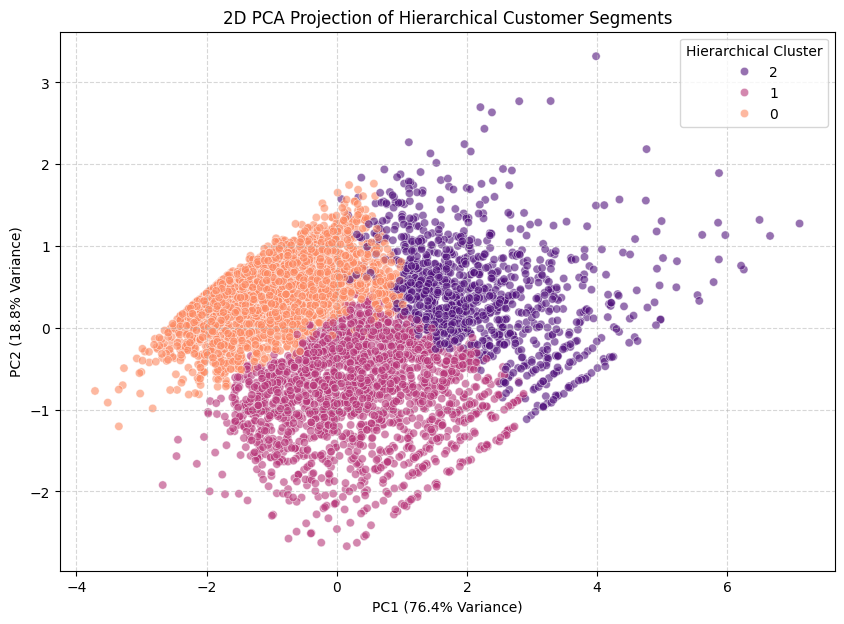

In [ ]:
# K-Means PCA Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=pca_df_full, palette='viridis', alpha=0.6)
plt.title('2D PCA Projection of K-Means Customer Segments')
plt.xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%} Variance)')
plt.legend(title='K-Means Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# DBSCAN PCA Scatter Plot
if 'DBSCAN_Cluster' in pca_df_full.columns:
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', data=pca_df_full, palette='plasma', alpha=0.6)
    plt.title('2D PCA Projection of DBSCAN Customer Segments')
    plt.xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%} Variance)')
    plt.ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%} Variance)')
    plt.legend(title='DBSCAN Cluster')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Hierarchical Clustering PCA Scatter Plot
if 'Hierarchical_Cluster' in pca_df_full.columns:
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='PC1', y='PC2', hue='Hierarchical_Cluster', data=pca_df_full, palette='magma', alpha=0.6)
    plt.title('2D PCA Projection of Hierarchical Customer Segments')
    plt.xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%} Variance)')
    plt.ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%} Variance)')
    plt.legend(title='Hierarchical Cluster')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

### Optional: 3D Interactive PCA Plot with Plotly

This interactive plot allows you to rotate and explore the customer segments in a 3D PCA space, which can provide a deeper understanding of the cluster separation using all three principal components.

In [ ]:
import plotly.express as px

# 3D Plot for K-Means Clusters
fig_pca_3d_kmeans = px.scatter_3d(
    pca_df_full,
    x='PC1',
    y='PC2',
    z='PC3',
    color='KMeans_Cluster',
    opacity=0.7,
    title='3D PCA Projection of K-Means Customer Segments',
    labels={'KMeans_Cluster': 'K-Means Cluster'},
    color_discrete_sequence=px.colors.qualitative.Vivid
)

fig_pca_3d_kmeans.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_pca_3d_kmeans.show()

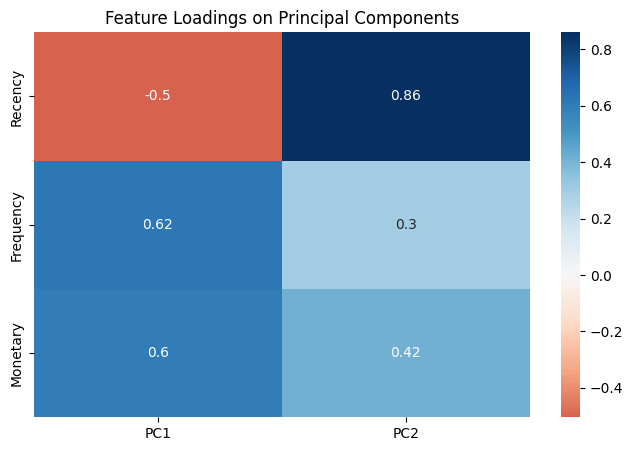

In [ ]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=['Recency', 'Frequency', 'Monetary'])

plt.figure(figsize=(8, 5))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('Feature Loadings on Principal Components')
plt.show()

#### Segment Radar Chart (Average Characteristics)
Finally, let's look at the relative strengths of each segment across the RFM dimensions.

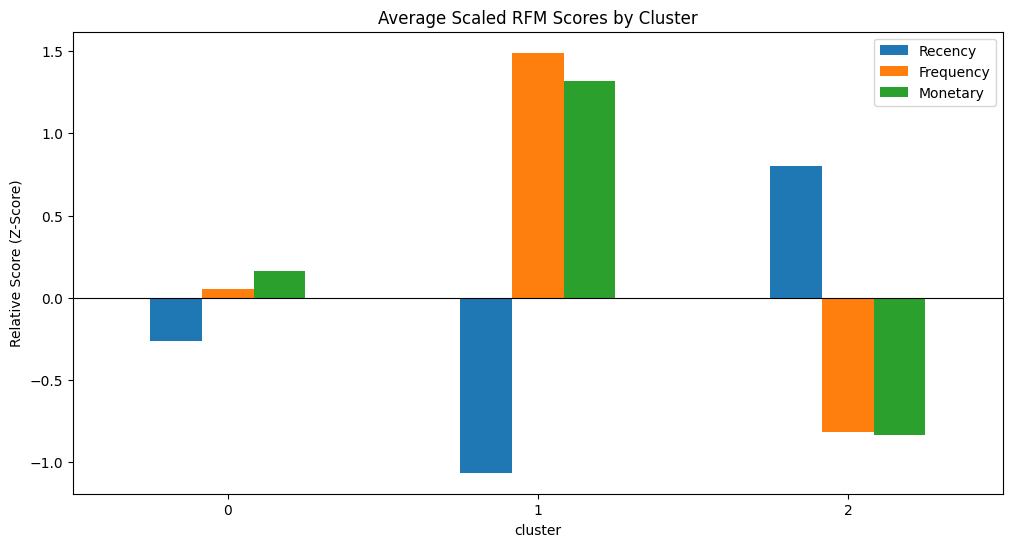

In [ ]:
# Calculate normalized means for a cleaner visualization
cluster_avg = X_df.groupby('cluster')[['recency_scaled', 'frequency_scaled', 'monetary_scaled']].mean()

cluster_avg.plot(kind='bar', figsize=(12, 6))
plt.title('Average Scaled RFM Scores by Cluster')
plt.ylabel('Relative Score (Z-Score)')
plt.xticks(rotation=0)
plt.legend(['Recency', 'Frequency', 'Monetary'])
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

 K-Means Cluster Profiles (Average Scaled RFM Scores)

This bar chart illustrates the average scaled Recency, Frequency, and Monetary scores for each of the three K-Means customer segments. It clearly visualizes the distinct characteristics of each cluster, aiding in their business interpretation. Higher (more positive) bars indicate higher values for that RFM dimension, while lower (more negative) bars indicate lower values. This plot highlights the 'Best Customers' with high frequency and monetary values and low recency, 'Regular Customers' with moderate scores, and 'Lapsed/Low-Value Customers' with high recency and low frequency and monetary values.

## Comparative Discussion and Recommendations

We have explored three distinct clustering algorithms—K-Means, DBSCAN, and Hierarchical Clustering—to segment our customer base based on their RFM (Recency, Frequency, Monetary) characteristics. Each method approaches clustering differently, leading to varying results in terms of cluster structure, performance, and business interpretability.

### 1. K-Means Clustering
*   **Performance (Internal Metrics):** K-Means achieved the highest Silhouette Score (0.347), indicating relatively well-separated and dense clusters. It also had a favorable Davies-Bouldin Index (1.037) and the highest Calinski-Harabasz Index (5215.592), suggesting good cluster quality and distinctness. These metrics consistently place K-Means as the quantitatively strongest performer in this analysis.
*   **Business Interpretability:** K-Means produced three distinct and highly interpretable segments: 'Best Customers', 'Regular Customers', and 'Lapsed/Low-Value Customers'. These segments are clear, actionable, and align well with typical customer lifecycle stages, making it easy to devise targeted marketing strategies.
*   **Strengths:** Simple to understand and implement, computationally efficient, and provides clear, spherical clusters when data supports it.
*   **Limitations:** Requires pre-defining the number of clusters (`k`), and can struggle with non-spherical or unevenly sized clusters. Outliers can heavily influence cluster centroids.

### 2. DBSCAN Clustering (Refined)
*   **Performance (Internal Metrics):** With an optimal `eps` and `min_samples`, refined DBSCAN resulted in 2 core clusters and identified a 'noise' cluster. Its Silhouette Score (0.279) was lower than K-Means, and its Davies-Bouldin (1.010) and Calinski-Harabasz (2898.703) scores were moderate. The large number of noise points (72 customers) also impacted the overall metric calculation (metrics were calculated excluding noise).
*   **Business Interpretability:** DBSCAN's strength lies in identifying 'noise' points, which in our case represented 'Extremely High-Value Outliers'. These are customers with unique, high-spending patterns that don't form a dense cluster with other customers, and they warrant special attention. The two core clusters were also interpretable ('Active & Consistent Buyers' and 'One-Time or Lapsed Low Spenders'), though less sharply defined than K-Means segments.
*   **Strengths:** Does not require specifying the number of clusters, effective at finding arbitrary-shaped clusters, and robust to outliers by classifying them as noise.
*   **Limitations:** Sensitive to parameter tuning (`eps` and `min_samples`), struggles with varying densities, and can leave a significant portion of data as noise if not dense enough.

### 3. Hierarchical Clustering
*   **Performance (Internal Metrics):** Hierarchical clustering, when set to 3 clusters, yielded a Silhouette Score of 0.323, a Davies-Bouldin Index of 1.069, and a Calinski-Harabasz Index of 3970.601. These metrics are generally good and comparable to K-Means, suggesting reasonable cluster quality.
*   **Business Interpretability:** Similar to K-Means, Hierarchical clustering also produced interpretable segments. The profiles showed distinct groups based on recency, frequency, and monetary values, albeit with slightly different boundaries compared to K-Means. The dendrogram provided a visual aid for understanding the hierarchy of clusters.
*   **Strengths:** Does not require pre-specifying `k` (though it can be chosen from the dendrogram), produces a hierarchy of clusters that can be useful for understanding relationships between segments.
*   **Limitations:** Can be computationally intensive for large datasets, and defining the number of clusters from a dendrogram can be subjective.

#### Overall Key Findings and Recommendation

For this customer segmentation task, **K-Means Clustering emerges as the most effective method.** It not only achieved the best internal validation scores but also produced the most clearly defined and business-actionable customer segments ('Best Customers', 'Regular Customers', 'Lapsed/Low-Value Customers'). Its straightforward nature makes the results easy to communicate and translate into strategic marketing actions.

*   **Key Findings:**
    *   **K-Means:** Successfully identified three clear customer segments: high-value, recent purchasers; moderate-value, regular purchasers; and low-value, less frequent/lapsed purchasers.
    *   **DBSCAN:** Uniquely identified a small but extremely high-value group of outlier customers, whose distinct behavior would be missed by other methods if not specifically engineered.
    *   **Hierarchical Clustering:** Provided a robust alternative with interpretable segments and the benefit of a visual dendrogram, though K-Means had slightly better metric scores.

#### Actionable Recommendations:

1.  **Nurture 'Best Customers' (K-Means Cluster 1):** Implement exclusive loyalty programs, VIP offers, personalized communications, and early access to new products. Focus on retention and encouraging advocacy.
2.  **Engage 'Regular Customers' (K-Means Cluster 0):** Develop strategies to increase their frequency and monetary value through targeted cross-selling, up-selling, and regular engagement to prevent churn. Consider subscription models or bundle offers.
3.  **Re-engage 'Lapsed/Low-Value Customers' (K-Means Cluster 2):** Launch win-back campaigns with attractive incentives, but also carefully evaluate the cost-effectiveness of re-engagement for these segments. For some, focus might shift to cost-efficient, broad-reach campaigns.
4.  **Special Handling for 'Extremely High-Value Outliers' (DBSCAN Cluster -1):** These customers (72 in our case) require white-glove service, dedicated account managers, and bespoke offers. Their unique value makes them critical to business success, and their behavior should be deeply investigated.
5.  **Utilize PCA Visualizations:** The 2D and 3D PCA plots provide a simple, visual explanation of how customer segments are separated, which can be invaluable for presenting findings to non-technical stakeholders.

A comprehensive summary of the key business findings from the clustering analysis, incorporating insights from all three methods and highlighting actionable recommendations.


## Summary:

### Data Analysis Key Findings

*   **K-Means Clustering Performance and Segments**: K-Means demonstrated the strongest quantitative performance with the highest Silhouette Score (0.347), a favorable Davies-Bouldin Index (1.037), and the highest Calinski-Harabasz Index (5215.592). It identified three clearly interpretable segments:
    *   **'Best Customers' (Cluster 1)**: Characterized by very low Recency (average 32.89 days), very high Frequency (average 19.11 orders), and very high Monetary value (average \$10,789.63).
    *   **'Regular Customers' (Cluster 0)**: The largest segment, showing moderate Recency (average 109.92 days), moderate Frequency (average 4.34 orders), and moderate Monetary value (average \$1,538.82).
    *   **'Lapsed/Low-Value Customers' (Cluster 2)**: Exhibited high Recency (average 375.09 days), very low Frequency (average 1.53 orders), and very low Monetary value (average \$397.52).
*   **DBSCAN Clustering's Unique Contribution**: Although DBSCAN had a lower Silhouette Score (0.279) than K-Means, it uniquely identified 72 customers as **'Extremely High-Value Outliers' (Cluster -1)**. These customers had moderate Recency (average $\sim$122 days), extremely high Frequency (average $\sim$62 orders), and extremely high Monetary value (average $\sim$\$71,675), indicating exceptional and distinct purchasing patterns that warrant specialized attention. It also identified 'Active & Consistent Buyers' (4190 customers) and 'One-Time or Lapsed Low Spenders' (1616 customers).
*   **Hierarchical Clustering as a Robust Alternative**: Hierarchical clustering also produced interpretable segments with good internal metrics (Silhouette Score 0.323, Davies-Bouldin Index 1.069, Calinski-Harabasz Index 3970.601), providing segments labeled as 'Lapsed or Low Engagement Customers' (2776 customers), 'Recent & Emerging Value Customers' (2036 customers), and 'High-Value Loyal Customers' (1066 customers).

### Insights

*   **K-Means is the most effective method for overall segmentation**: Due to its superior internal validation scores and the clear, actionable, and business-interpretable segments it produced, K-Means is recommended as the primary approach for customer segmentation, providing a solid foundation for targeted marketing strategies.
*   **Tailored Marketing Strategies based on K-Means Segments**:
    *   **'Best Customers'**: Implement exclusive loyalty programs, VIP offers, and personalized communications to ensure retention and advocacy.
    *   **'Regular Customers'**: Focus on increasing engagement and purchase value through targeted cross-selling, up-selling, and regular promotions.
    *   **'Lapsed/Low-Value Customers'**: Evaluate the cost-effectiveness of re-engagement campaigns with attractive incentives.
*   **Strategic Management of DBSCAN's 'Extremely High-Value Outliers'**: These 72 customers represent a critical group that requires bespoke attention, dedicated account management, and in-depth analysis to understand and maintain their unparalleled loyalty and contribution.
*   **Leverage PCA Visualizations**: Utilize 2D and 3D PCA plots to effectively communicate segment separation and findings to non-technical stakeholders, enhancing understanding and buy-in for proposed strategies.
